# Family Guy — Exploratory Data Analysis
*A data-driven look at 21 seasons, 400 episodes, ratings, guest stars, musical numbers and special episodes.*

---

**Dataset:** Family Guy Dataset (Kaggle) — 400 episodes, 21 columns  
**Author:** Nano Vives  
**Tools:** Python · Pandas · Matplotlib · Seaborn

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Cleaning](#2-data-cleaning)
3. [Ratings Overview](#3-ratings-overview)
4. [Directors & Writers](#4-directors--writers)
5. [Musical Episodes](#5-musical-episodes)
6. [Guest Stars](#6-guest-stars)
7. [Special Episodes (Running Time)](#7-special-episodes-running-time)
8. [Conclusions & Key Findings](#8-conclusions--key-findings)


## 1. Setup & Data Loading

First we import all the libraries we'll need throughout the notebook. We also set up two custom fonts (`Luckiest Guy` for titles and `Comic Neue` for body text) that give the charts a cartoon feel matching the show's aesthetic, and define a consistent color palette so every chart looks like it belongs to the same project.

> **Note for reproducibility:** download the two font files and place them in a `fonts/` folder at the root of this repo. The paths below are relative so they'll work on any machine.

The fonts are free:
- [Luckiest Guy](https://fonts.google.com/specimen/Luckiest+Guy) → save as `fonts/LuckiestGuy-Regular.ttf`
- [Comic Neue](https://fonts.google.com/specimen/Comic+Neue) → save as `fonts/ComicNeue-Regular.ttf`


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.lines as mlines
from matplotlib import font_manager
import seaborn as sns

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Font setup (Luckiest Guy for titles, Comic Neue for body text)
# Both fonts live in a fonts/ folder relative to this notebook.
# If matplotlib can't find them, it falls back to the default font.
import os

font_path = os.path.join('fonts', 'LuckiestGuy-Regular.ttf')
font_path_regular = os.path.join('fonts', 'ComicNeue-Regular.ttf')

if os.path.exists(font_path):
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
else:
    prop = font_manager.FontProperties()  # system default fallback
    print('⚠️  Luckiest Guy font not found — using system default. See README for setup.')

if os.path.exists(font_path_regular):
    font_manager.fontManager.addfont(font_path_regular)
    prop_regular = font_manager.FontProperties(fname=font_path_regular)
else:
    prop_regular = font_manager.FontProperties()
    print('⚠️  Comic Neue font not found — using system default.')

# Global color palette — consistent across all charts
BG     = '#FFF5E1'  # warm cream background
BLUE   = '#00A0D4'  # main accent (titles, labels)
PINK   = '#E06EAA'  # secondary accent
GREEN  = '#21E3B8'  # primary data color
YELLOW = '#FFD700'  # highlight / mean markers
BLACK  = 'black'

# Reusable path-effect helpers
# These add cartoon-style outlines to text — a thick black stroke behind the colored text.
def cartoon_effect(lw=5):
    """Thin black outline — used on axis labels and tick labels."""
    return [path_effects.withStroke(linewidth=lw, foreground=BLACK)]

def title_effect():
    """Bold outline + drop shadow — used on chart titles."""
    return [
        path_effects.withStroke(linewidth=8, foreground=BLACK),
        path_effects.SimplePatchShadow(offset=(3, -3), shadow_rgbFace=BLACK, alpha=1),
        path_effects.Normal()
    ]


In [2]:
# Load the dataset
# The CSV should be in a data/ folder at the root of the repo.
# Download it from Kaggle: https://https://www.kaggle.com/datasets/iamsouravbanerjee/family-guy-dataset
df = pd.read_csv(os.path.join('data', 'Family Guy Dataset.csv'))

print(f'Shape: {df.shape}')  # rows x columns
df.head(5)  # quick look at the first 5 rows


Shape: (400, 21)


,Season,No. of Episode (Season),No. of Episode (Overall),Title of the Episode,Director,Assistant Director,Written by,Storyboard by,Guest Starring,Featuring,...,Musical Numbers,Original Air Date,Product Code,U.S. Viewers (Millions),TV Rating,Running Time (Minutes),Aspect Ratio,Production Companies,IMDb Rating,Synopsys
0,1,1,1,Death Has a Shadow,Peter Shin,NaN,Seth MacFarlane,"Shawna Cha, John Rice, Mark Zoeller",NaN,"Peter Griffin, Lois Griffin, Brian Griffin, St...",...,NaN,"January 31, 1999",1ACX01,22.00,TV-14,30,1.33 : 1,"20th Century Fox Television, Fuzzy Door Produc...",7.7,Peter applies for welfare to support his famil...
1,1,2,2,I Never Met the Dead Man,Michael Dante DiMartino,NaN,Chris Sheridan,"Ron Brewer, Don Sciore",NaN,"Peter Griffin, Meg Griffin, William Shatner",...,NaN,"April 11, 1999",1ACX02,14.50,TV-14,23,1.33 : 1,"20th Century Fox Television, Fuzzy Door Produc...",7.5,Peter has become addicted to television. While...
2,1,3,3,Chitty Chitty Death Bang,Dominic Polcino,NaN,Danny Smith,"Ron Brewer, Eric Fredrickson, Bill Riling","John O'Hurley, Waylon Jennings","Peter, Meg, Lois, Stewie, Jennifer",...,NaN,"April 18, 1999",1ACX04,13.78,TV-14,30,1.33 : 1,"20th Century Fox Television, Fuzzy Door Produc...",7.6,Peter accidentally loses the reservation for S...
3,1,4,4,Mind Over Murder,Roy Allen Smith,NaN,Neil Goldman & Garrett Donovan,"Jim Keeshen, Ron Brewer, Shawna Cha, Ken Laram...","Alex Rocco, Leslie Uggams","Peter Griffin, Lois Griffin, Stewie Griffin",...,"You'll Never Know, You Made Me Love You, Don't...","April 25, 1999",1ACX03,11.69,TV-14,23,1.33 : 1,"20th Century Fox Television, Fuzzy Door Produc...",7.4,Stewie has begun teething; Lois explains to hi...
4,1,5,5,A Hero Sits Next Door,Monte Young,NaN,Mike Barker & Matt Weitzman,"Ron Brewer, Don Sciore",Michelle Kwan,"Peter Griffin, Joe Swanson, Bonnie Swanson",...,Jesus Loves Me,"May 2, 1999",1ACX05,12.61,TV-14,30,1.33 : 1,"20th Century Fox Television, Fuzzy Door Produc...",7.4,After Peter injures the Happy-Go-Lucky Toy Fac...


## 2. Data Cleaning

The dataset is in pretty good shape — 400 rows, only a handful of NaNs. The one column that needs work is `Original Air Date`: in the raw CSV some entries contain multiple dates separated by `;` (e.g. a DVD release date and the broadcast date), plus annotations like `(Fox)` or `(DVD)` in parentheses. We extract just the first date, strip the noise, and parse it as a proper `datetime` object so we can sort and filter by date later if needed.


In [3]:
# Fix Original Air Date
# Problem: some entries look like 'January 31, 1999; February 5, 1999 (DVD)'
# Step 1: split on ';' and keep only the first part
# Step 2: remove anything in parentheses with a regex
# Step 3: strip whitespace and parse as datetime
df['Original Air Date'] = (
    df['Original Air Date']
    .astype(str)
    .str.split(';').str[0]                     # keep first date only
    .str.replace(r'\(.*?\)', '', regex=True)   # remove (DVD), (Fox), etc.
    .str.strip()
    .pipe(pd.to_datetime, errors='coerce')      # parse as datetime; unparseable → NaT
)

# Schema check: verify all dtypes look correct after cleaning
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Season                    400 non-null    int64         
 1   No. of Episode (Season)   400 non-null    int64         
 2   No. of Episode (Overall)  400 non-null    int64         
 3   Title of the Episode      400 non-null    object        
 4   Director                  400 non-null    object        
 5   Assistant Director        372 non-null    object        
 6   Written by                400 non-null    object        
 7   Storyboard by             400 non-null    object        
 8   Guest Starring            250 non-null    object        
 9   Featuring                 400 non-null    object        
 10  Also Appearing            400 non-null    object        
 11  Musical Numbers           261 non-null    object        
 12  Original Air Date     

## 3. Ratings Overview

Let's start with the big picture: how do IMDb ratings evolve across 21 seasons? We'll look at the average per season, but also the range (best vs worst episode) to understand how consistent — or inconsistent — each season is.

Key questions:
- Which season had the best average rating?
- How wide is the gap between the best and worst episode in each season?
- Is the show getting better or worse over time?


In [4]:
# Summary stats per season
# We compute mean, standard deviation, min and max rating for each of the 21 seasons.
# The std (standard deviation) tells us how spread out ratings are within a season —
# a high std means the season has some great episodes and some terrible ones.
df_desc = (
    df.groupby('Season')['IMDb Rating']
    .describe()
    .round(1)
    [['mean', 'std', 'min', 'max']]
    .reset_index()
)
df_desc


,Season,mean,std,min,max
0,1,7.5,0.2,7.2,7.7
1,2,7.6,0.4,6.9,8.2
2,3,7.6,0.3,6.7,8.1
3,4,7.6,0.3,7.2,8.5
4,5,7.6,0.3,7.2,8.4
5,6,7.5,0.5,6.8,8.3
6,7,7.5,0.5,6.4,8.2
7,8,7.3,0.5,6.8,9.1
8,9,7.3,0.6,6.5,8.6
9,10,7.2,0.5,6.4,8.8


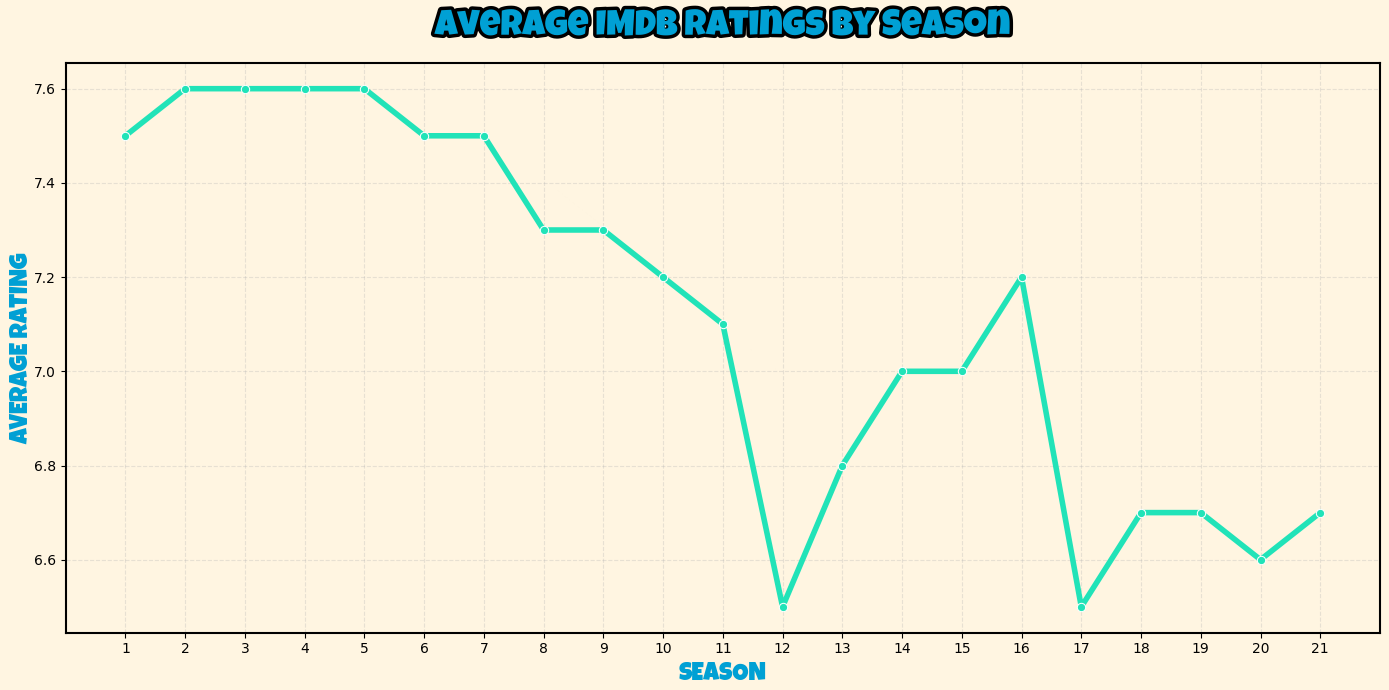

In [5]:
# Line chart: average rating per season
# A simple but effective overview of the show's quality trajectory.
# Each dot = one season's average; the line connects them chronologically.
plt.style.use('default')
plt.figure(figsize=(14, 7))

# Get the current figure and axes objects
# Figure = entire window/canvas
# Axes = the actual chart area where the data is plotted
fig = plt.gcf()
ax  = plt.gca()
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sns.lineplot(
    data=df_desc, x='Season', y='mean',
    marker='o', linewidth=4, color=GREEN
)

title_obj = plt.title(
    'Average IMDb Ratings by Season',
    fontproperties=prop, fontsize=26, color=BLUE, pad=20
)
title_obj.set_path_effects([path_effects.withStroke(linewidth=5, foreground=BLACK)])

plt.xlabel('SEASON',         fontproperties=prop, fontsize=18, color=BLUE)
plt.ylabel('AVERAGE RATING', fontproperties=prop, fontsize=18, color=BLUE)
plt.xticks(range(1, 22))  # one tick per season
plt.grid(visible=True, alpha=0.3, linestyle='--')

for spine in ax.spines.values():
    spine.set_color(BLACK)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


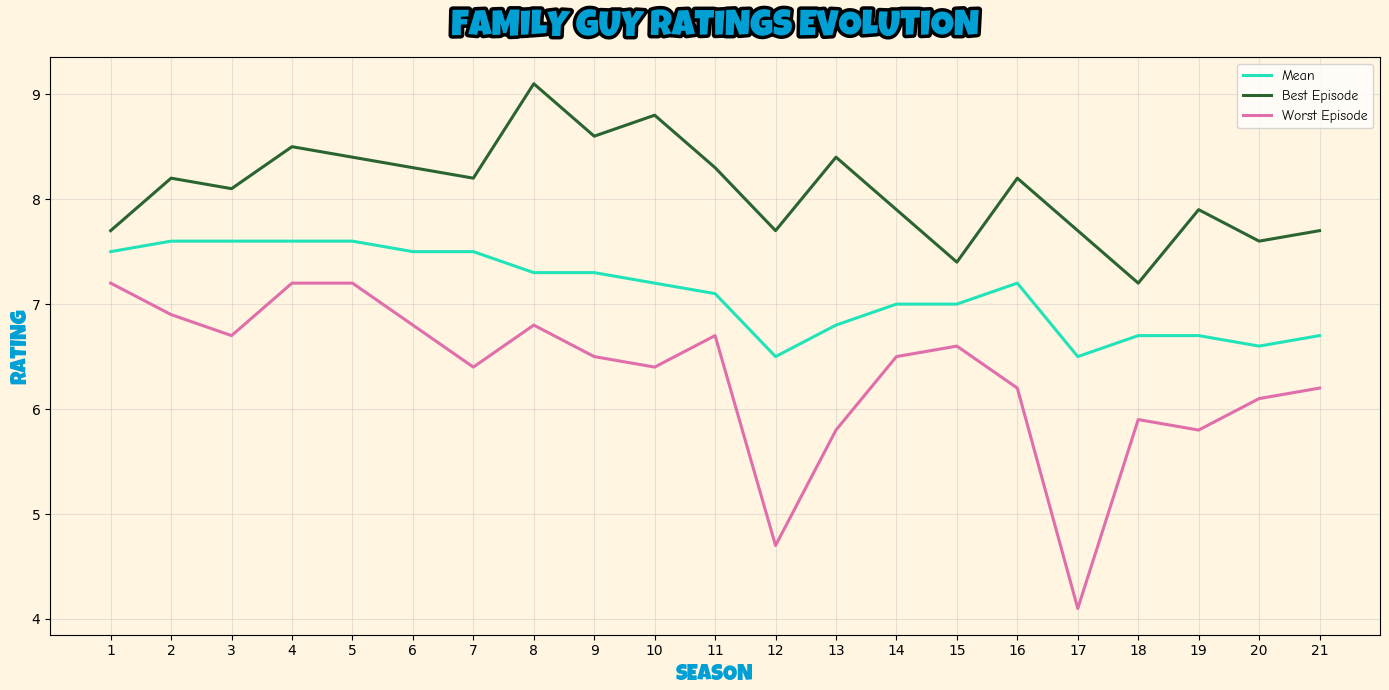

In [6]:
# Line chart: mean / best / worst episode per season
# Plotting three lines at once lets us see not just the average trend,
# but also how wide the quality gap within each season is.
# A wide spread between best and worst = polarising season with highs and lows.
plt.style.use('default')
plt.figure(figsize=(14, 7))

fig = plt.gcf()
ax  = plt.gca()
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sns.lineplot(data=df_desc, x='Season', y='mean', label='Mean', color=GREEN, linewidth=2.2)
sns.lineplot(data=df_desc, x='Season', y='max', label='Best Episode', color='#2A6431', linewidth=2.2)
sns.lineplot(data=df_desc, x='Season', y='min', label='Worst Episode', color=PINK, linewidth=2.2)

plt.legend(prop=prop_regular)
plt.xlabel('SEASON', fontproperties=prop, fontsize=16, color=BLUE)
plt.ylabel('RATING', fontproperties=prop, fontsize=16, color=BLUE)

title_obj = plt.title(
    'FAMILY GUY RATINGS EVOLUTION',
    fontproperties=prop, fontsize=26, color=BLUE, pad=16
)
title_obj.set_path_effects([path_effects.withStroke(linewidth=5, foreground=BLACK)])

plt.xticks(range(1, 22))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


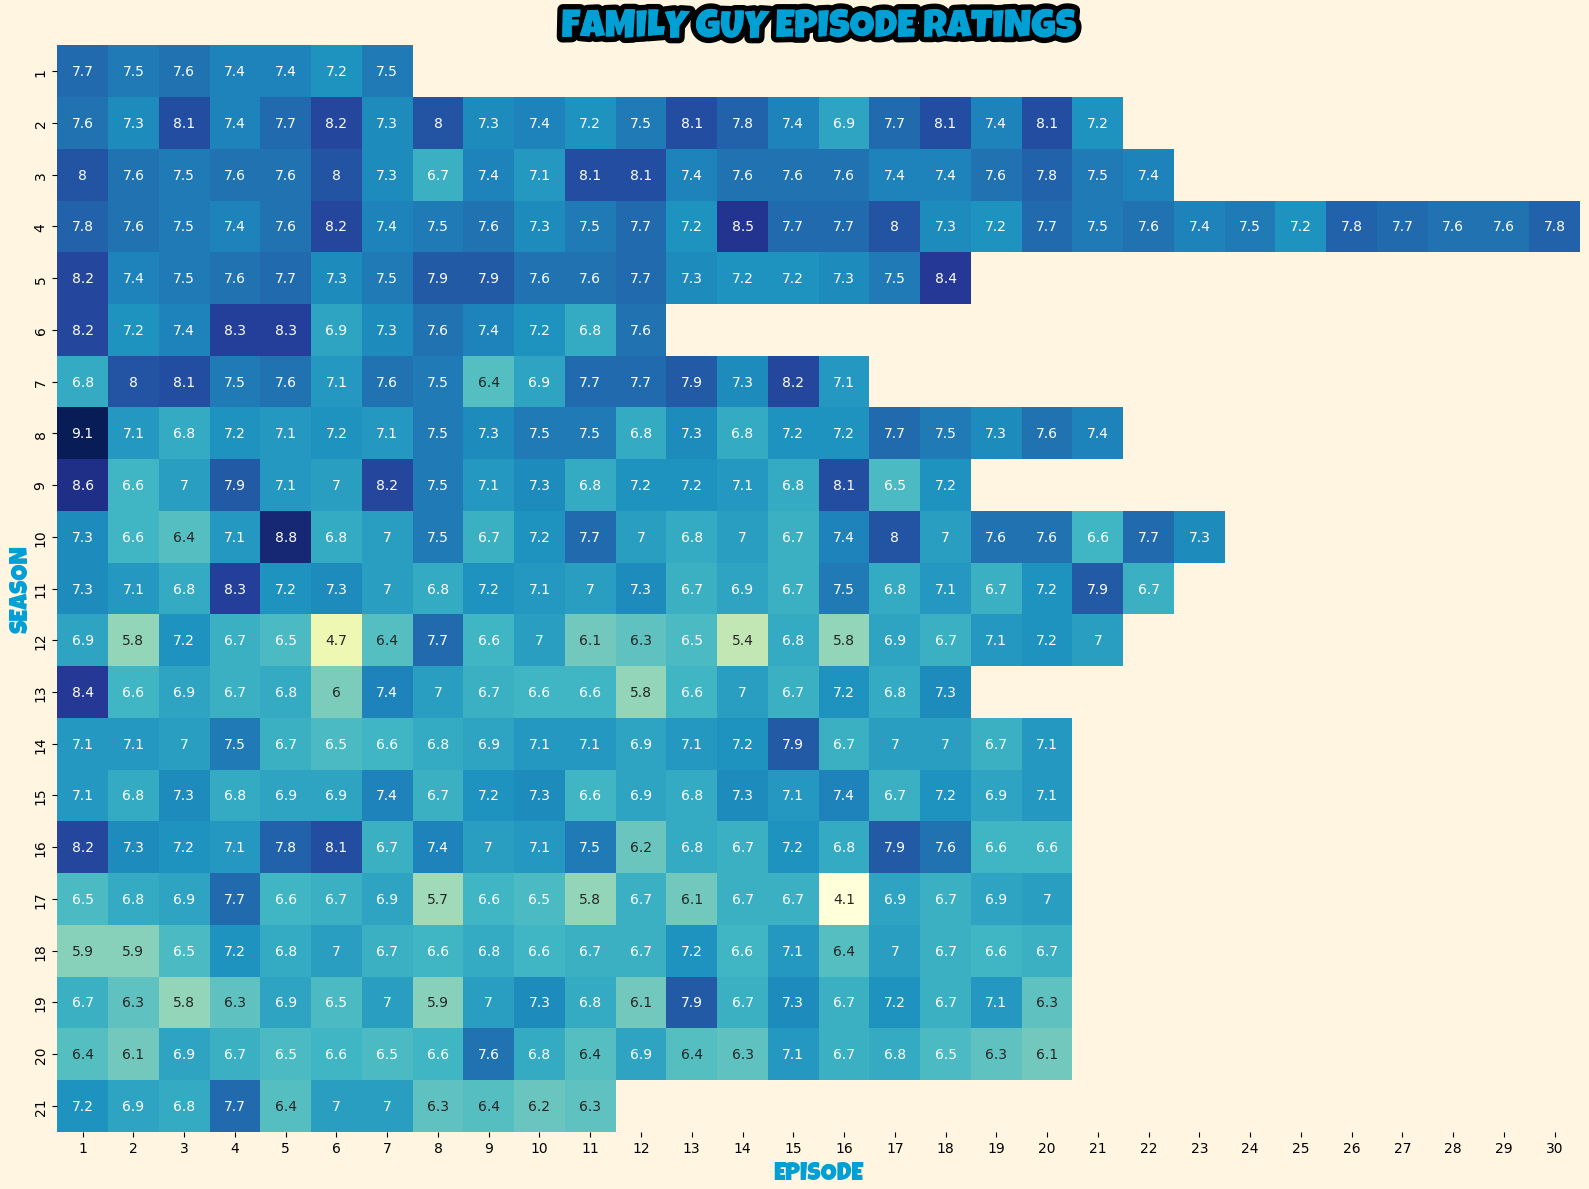

In [7]:
# Heatmap: episode-by-episode rating grid
# This is the most granular ratings view in the notebook.
# Each cell = one episode; rows = seasons, columns = episode number within the season.
# Empty cells appear where seasons have fewer episodes than the longest season.
# The color gradient makes it easy to spot clusters of low or high ratings at a glance.
episode_performance_df = df.pivot(
    index='Season',
    columns='No. of Episode (Season)',
    values='IMDb Rating'
)

plt.figure(figsize=(16, 12))
fig = plt.gcf()
ax  = plt.gca()
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sns.heatmap(episode_performance_df, annot=True, cmap='YlGnBu', cbar=False)

plt.xlabel('EPISODE', fontproperties=prop, fontsize=18, color=BLUE)
plt.ylabel('SEASON',  fontproperties=prop, fontsize=18, color=BLUE)
title_obj = plt.title('FAMILY GUY EPISODE RATINGS', fontproperties=prop, fontsize=28, color=BLUE)
title_obj.set_path_effects(title_effect())

plt.tight_layout()
plt.show()


## 4. Directors & Writers

Family Guy has been running for over 25 years, so it's had a lot of people behind the camera and at the keyboard. Here we look at who's been the most prolific — the top 12 directors and top 12 writers by episode count.

Note that a single episode can have multiple writers credited together (e.g. `Neil Goldman & Garrett Donovan`), and we're treating each unique credit string as one entry. So a writer who sometimes works solo and sometimes in pairs will appear as separate entries.


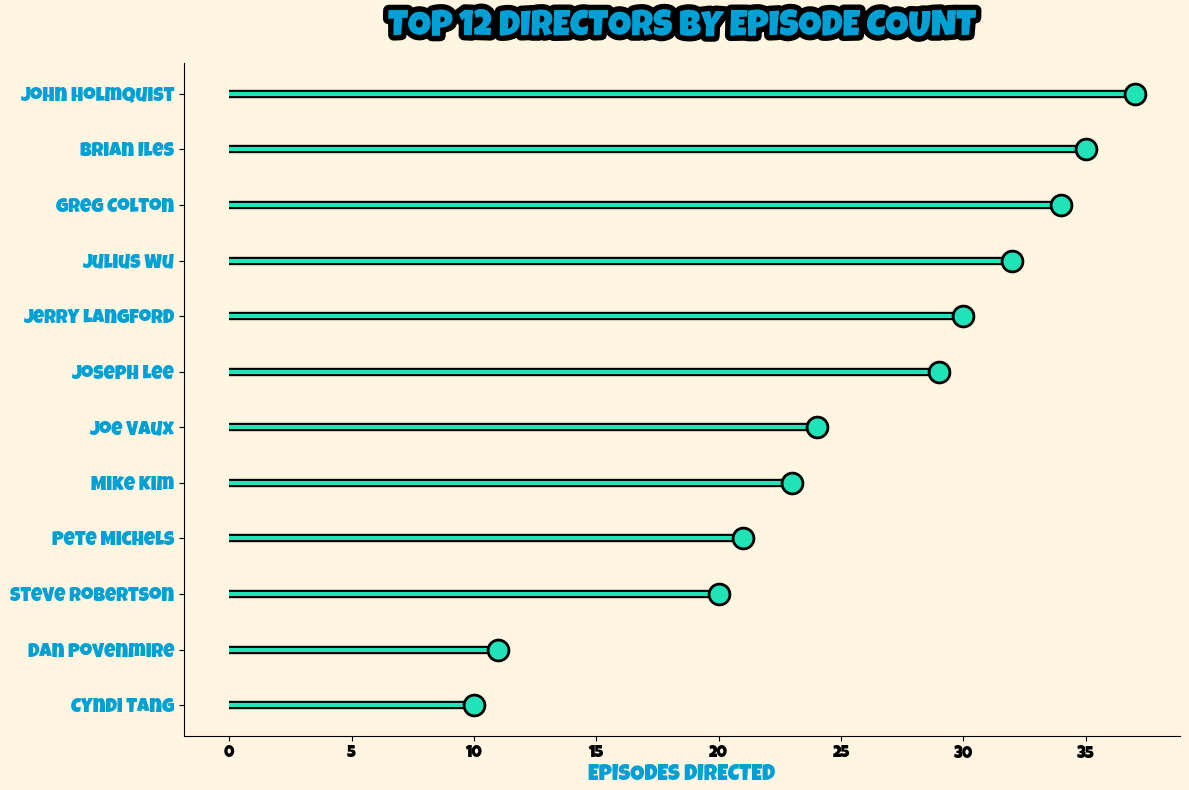

In [8]:
# Top 12 directors by episode count
# value_counts() gives us a frequency table — most common first.
# [:12] keeps the top 12, and .iloc[::-1] reverses the order
# so that when we plot horizontally, the #1 director appears at the top.
directores = df['Director'].value_counts()[:12].iloc[::-1]

nombres = directores.index
conteos = directores.values

plt.figure(figsize=(12, 8))
fig = plt.gcf()
ax  = plt.gca()
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Lollipop chart: two hlines() calls create the stick (thick black + thinner green on top)
plt.hlines(y=nombres, xmin=0, xmax=conteos, color=BLACK, linewidth=6)
plt.hlines(y=nombres, xmin=0, xmax=conteos, color=GREEN,  linewidth=3)
# The circle at the end of each stick
plt.plot(conteos, nombres, 'o', markersize=15,
         color=GREEN, markeredgecolor=BLACK, markeredgewidth=2)

plt.yticks(fontproperties=prop, fontsize=14, color=BLUE)

title_obj = plt.title('TOP 12 DIRECTORS BY EPISODE COUNT',
                       fontproperties=prop, fontsize=26, color=BLUE, pad=20)
title_obj.set_path_effects(title_effect())

plt.xlabel('EPISODES DIRECTED', fontproperties=prop, fontsize=16, color=BLUE)
plt.xticks(fontproperties=prop, fontsize=12, color=BLACK)

#Remove borders, change the left border color and change the bottom border color

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(BLACK)
ax.spines['bottom'].set_color(BLACK)

plt.tight_layout()
plt.show()


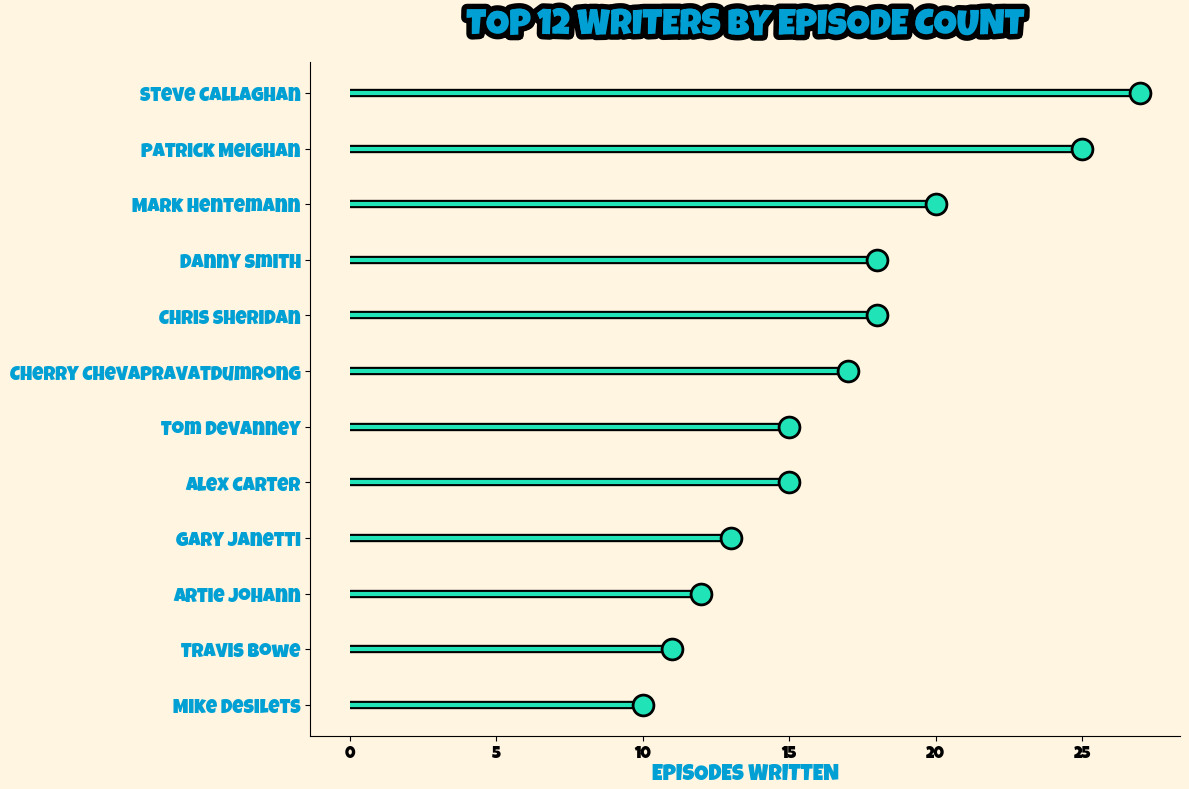

In [9]:
# Top 12 writers by episode count
# Same approach as directors — identical chart structure, different column.
# This makes it easy to compare: who writes more, who directs more?
written_by = df['Written by'].value_counts()[:12].iloc[::-1]

nombres = written_by.index
conteos = written_by.values

plt.figure(figsize=(12, 8))
fig = plt.gcf()
ax  = plt.gca()
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

plt.hlines(y=nombres, xmin=0, xmax=conteos, color=BLACK, linewidth=6)
plt.hlines(y=nombres, xmin=0, xmax=conteos, color=GREEN,  linewidth=3)
plt.plot(conteos, nombres, 'o', markersize=15,
         color=GREEN, markeredgecolor=BLACK, markeredgewidth=2)

plt.yticks(fontproperties=prop, fontsize=14, color=BLUE)

title_obj = plt.title('TOP 12 WRITERS BY EPISODE COUNT',
                       fontproperties=prop, fontsize=26, color=BLUE, pad=20)
title_obj.set_path_effects(title_effect())

plt.xlabel('EPISODES WRITTEN', fontproperties=prop, fontsize=16, color=BLUE)
plt.xticks(fontproperties=prop, fontsize=12, color=BLACK)

#Remove borders, change the left border color and change the bottom border color

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(BLACK)
ax.spines['bottom'].set_color(BLACK)

plt.tight_layout()
plt.show()


## 5. Musical Episodes

261 out of 400 episodes (65%) feature at least one musical number — Family Guy really loves to sing. But do the episodes with songs actually rate higher? And which songs keep coming back?

**Key findings:**
- Episodes with music average **7.21** vs **6.97** for those without — a +0.24 gap.
- In seasons 3, 6 and 13 the difference rises to +0.4 points.
- Season 7 is the only season where **every single episode** has a musical number.
- *Surfin' Bird* is the most-used song in the entire series (7 appearances).


In [10]:
# Feature engineering for musical episodes

# has_music: True if the episode has at least one song (column is not NaN)
df['has_music']   = df['Musical Numbers'].notna()
df['music_label'] = df['has_music'].map({True: 'With music', False: 'Without music'})

# Count how many songs each episode has (split on comma, count resulting items)
df['num_songs'] = df['Musical Numbers'].str.split(',').str.len()

# Explode the Musical Numbers column: split each comma-separated list,
# then 'explode' so each individual song title gets its own row.
# This lets us count how many times each song appears across all episodes.
all_songs = (
    df['Musical Numbers']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()  # remove accidental leading/trailing spaces
)
top_songs = all_songs.value_counts().head(10).iloc[::-1]
top_songs = top_songs[top_songs.index != 'TBA']  # remove placeholder entries

# Average rating per season, split by musical vs non-musical
# unstack() pivots the has_music boolean into two columns: True and False
by_season_music = df.groupby(['Season', 'has_music'])['IMDb Rating'].mean().unstack()
by_season_music.columns = ['Without music', 'With music']


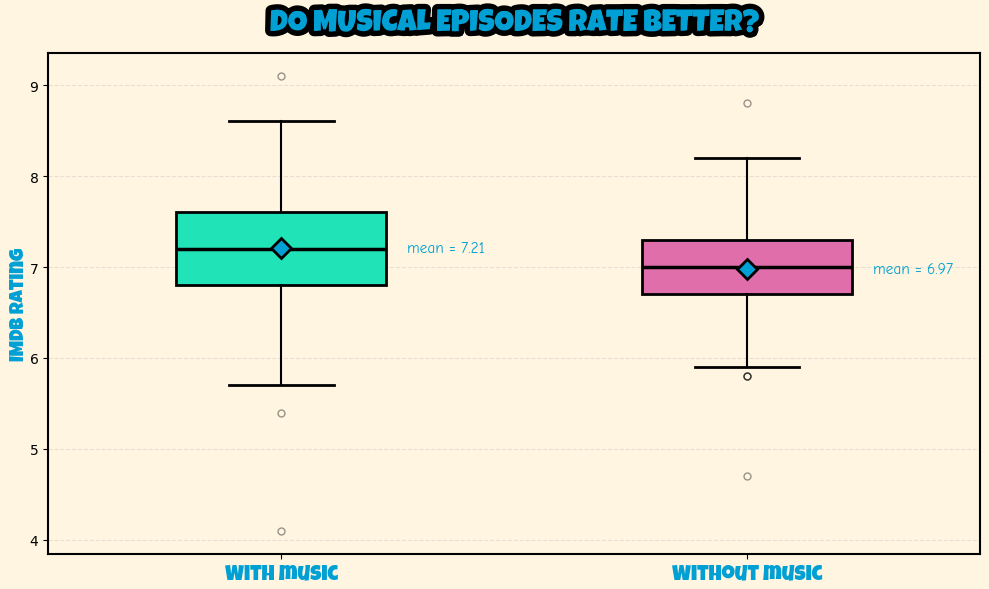

In [11]:
# Boxplot: rating distribution — with music vs without
# A boxplot shows median, interquartile range, and outliers all at once.
# The diamond marker (D) shows the mean — different from the median when data is skewed.
# We annotate the mean value directly on the chart so it's easy to read.
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

groups = [
    df[df['has_music']]['IMDb Rating'].dropna(),
    df[~df['has_music']]['IMDb Rating'].dropna()
]
labels = ['With music', 'Without music']
colors = [GREEN, PINK]

# Create the boxplot chart and customize the median line, whiskers, caps and outliers to improve readability and match the visual style of the project
bp = ax.boxplot(
    groups, patch_artist=True, widths=0.45,
    medianprops=dict(color=BLACK, linewidth=2.5),
    whiskerprops=dict(color=BLACK, linewidth=1.5),
    capprops=dict(color=BLACK, linewidth=2),
    flierprops=dict(marker='o', color=BLACK, alpha=0.4, markersize=5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(BLACK)
    patch.set_linewidth(2)

# Diamond marker for the mean + text annotation
for i, group in enumerate(groups, start=1):
    ax.plot(i, group.mean(), 'D', color=BLUE,
            markersize=10, markeredgecolor=BLACK, markeredgewidth=2, zorder=5)
    ax.annotate(f'mean = {group.mean():.2f}',
                xy=(i + 0.27, group.mean()),
                fontproperties=prop_regular, fontsize=11, color=BLUE, va='center')

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontproperties=prop, fontsize=15, color=BLUE)

title_obj = ax.set_title('DO MUSICAL EPISODES RATE BETTER?',
                          fontproperties=prop, fontsize=22, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_ylabel('IMDb Rating', fontproperties=prop, fontsize=14, color=BLUE)
ax.grid(visible=True, axis='y', alpha=0.3, linestyle='--')

for spine in ax.spines.values():
    spine.set_color(BLACK)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


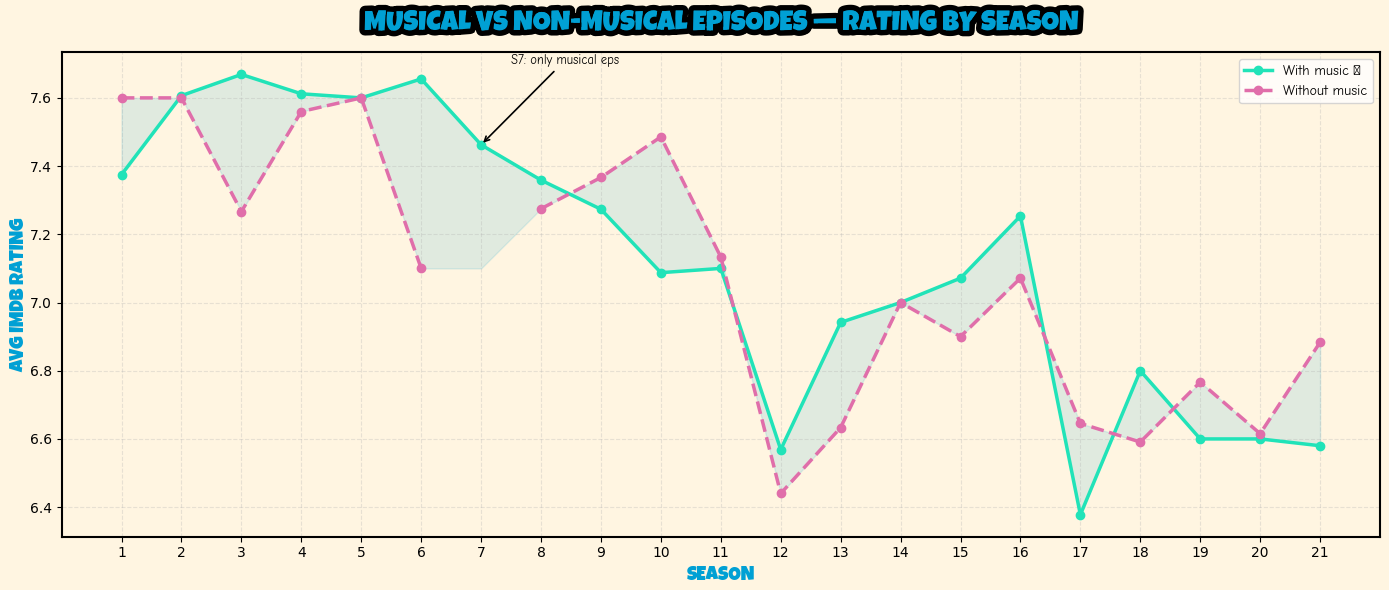

In [12]:
# Line chart: musical vs non-musical rating by season
# Instead of a single average, this shows the gap season by season.
# The shaded area between the two lines makes the gap visually intuitive:
# wider shade = bigger advantage for musical episodes that season.
# Note: Season 7 has no non-musical episodes, so the dashed line has a gap there.
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(by_season_music.index, by_season_music['With music'],
        marker='o', linewidth=2.5, color=GREEN, label='With music 🎵')
ax.plot(by_season_music.index, by_season_music['Without music'],
        marker='o', linewidth=2.5, color=PINK, linestyle='--', label='Without music')

# fill_between() shades the area between the two lines
# ffill() forward-fills NaN values (Season 7) so the shading doesn't have holes
ax.fill_between(by_season_music.index,
                by_season_music['With music'].ffill(),
                by_season_music['Without music'].ffill(),
                alpha=0.12, color=BLUE)

title_obj = ax.set_title('MUSICAL VS NON-MUSICAL EPISODES — RATING BY SEASON',
                          fontproperties=prop, fontsize=20, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_xlabel('SEASON', fontproperties=prop, fontsize=14, color=BLUE)
ax.set_ylabel('AVG IMDb RATING', fontproperties=prop, fontsize=14, color=BLUE)
ax.set_xticks(range(1, 22))
ax.grid(alpha=0.3, linestyle='--')
ax.legend(prop=prop_regular, fontsize=11)

# Customize all chart borders (spines) by changing their color and thickness for a cleaner visual style
for spine in ax.spines.values():
    spine.set_color(BLACK)
    spine.set_linewidth(1.5)

# Annotation pointing out the Season 7 anomaly
ax.annotate('S7: only musical eps',
            xy=(7, by_season_music.loc[7, 'With music']),
            xytext=(7.5, 7.7),
            fontproperties=prop_regular, fontsize=9, color=BLACK,
            arrowprops=dict(arrowstyle='->', color=BLACK, lw=1.2))

plt.tight_layout()
plt.show()


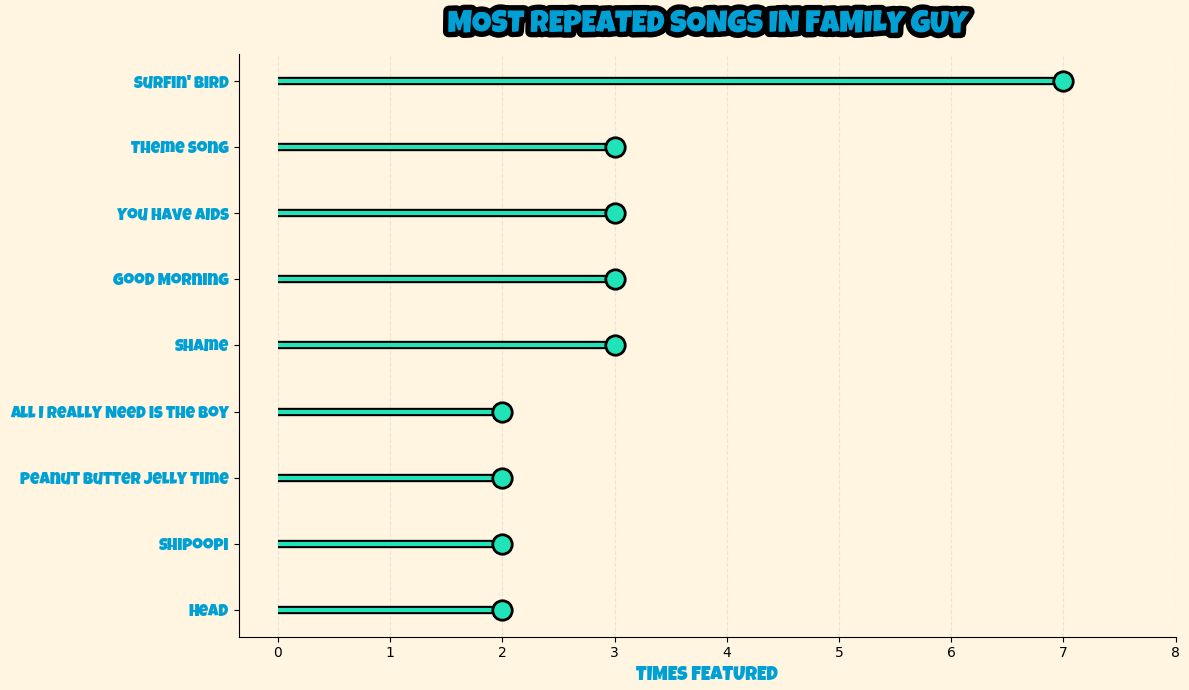

In [13]:
# Lollipop: most repeated songs across the series
# Family Guy recycles certain songs obsessively (looking at you, Surfin' Bird).
# This chart shows the top 10 most-used songs by number of episode appearances.
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

names = top_songs.index
counts = top_songs.values

ax.hlines(y=names, xmin=0, xmax=counts, color=BLACK, linewidth=6)
ax.hlines(y=names, xmin=0, xmax=counts, color=GREEN, linewidth=3)
ax.plot(counts, names, 'o', markersize=14,
        color=GREEN, markeredgecolor=BLACK, markeredgewidth=2)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontproperties=prop, fontsize=12, color=BLUE)

title_obj = ax.set_title('MOST REPEATED SONGS IN FAMILY GUY',
                        fontproperties=prop, fontsize=22, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_xlabel('TIMES FEATURED', fontproperties=prop, fontsize=14, color=BLUE)
ax.set_xticks(range(0, counts.max() + 2))  # integer ticks only

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(BLACK)
ax.spines['bottom'].set_color(BLACK)
ax.grid(axis='x', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()


## 6. Guest Stars

250 of 400 episodes (62.5%) feature at least one guest star. That's a huge number — Family Guy has basically been running a celebrity showcase alongside the actual show. But does having a famous face in the episode actually make it better?

We explore three angles: overall rating impact, who appears most, and whether frequent guests are actually the best-rated ones.

**Key findings:**
- Episodes with guest stars average **7.19** vs **7.02** without — small but consistent.
- **Drew Barrymore, Patrick Stewart and Carrie Fisher** each appear in 9 episodes — the series record.
- **Wallace Shawn** appears only 3 times but has the highest average rating (7.93) of any recurring guest.
- In later seasons (8, 10+) the guest-star advantage disappears — in the early years, guests felt special; later on they became routine.


In [14]:
# Feature engineering for guest star analysis

# has_guest: True if the Guest Starring column is not empty
df['has_guest']   = df['Guest Starring'].notna()
df['guest_label'] = df['has_guest'].map({True: 'With guest', False: 'Without guest'})

# Explode the guest list: each episode can have multiple guests separated by commas. 
# assign() creates a new column with the list of guests per episode, then explode() gives each guest their own row so we can count individually.
guests_exp = (
    df[['Guest Starring', 'IMDb Rating']]
    .dropna()
    .assign(guest=df['Guest Starring'].str.split(','))
    .explode('guest')
)
guests_exp['guest'] = guests_exp['guest'].str.strip()
guests_exp = guests_exp[guests_exp['guest'] != 'Jr.']  # parsing artifact ('Robert Downey Jr.' splits awkwardly)

# Top 12 most frequent guests across all episodes
top_guests = guests_exp['guest'].value_counts().head(12).iloc[::-1]

# Recurring guests (appeared in 3 or more episodes): count + average rating
# This lets us compare volume (appearances) vs quality (avg rating of those episodes)
guest_stats = (
    guests_exp
    .groupby('guest')
    .agg(apariciones=('IMDb Rating', 'count'), avg_rating=('IMDb Rating', 'mean'))
    .query('apariciones >= 3')
    .sort_values('avg_rating', ascending=False)
)

# Average rating per season, split by guest / no guest
by_season_guest = df.groupby(['Season', 'has_guest'])['IMDb Rating'].mean().unstack()
by_season_guest.columns = ['Without guest', 'With guest']


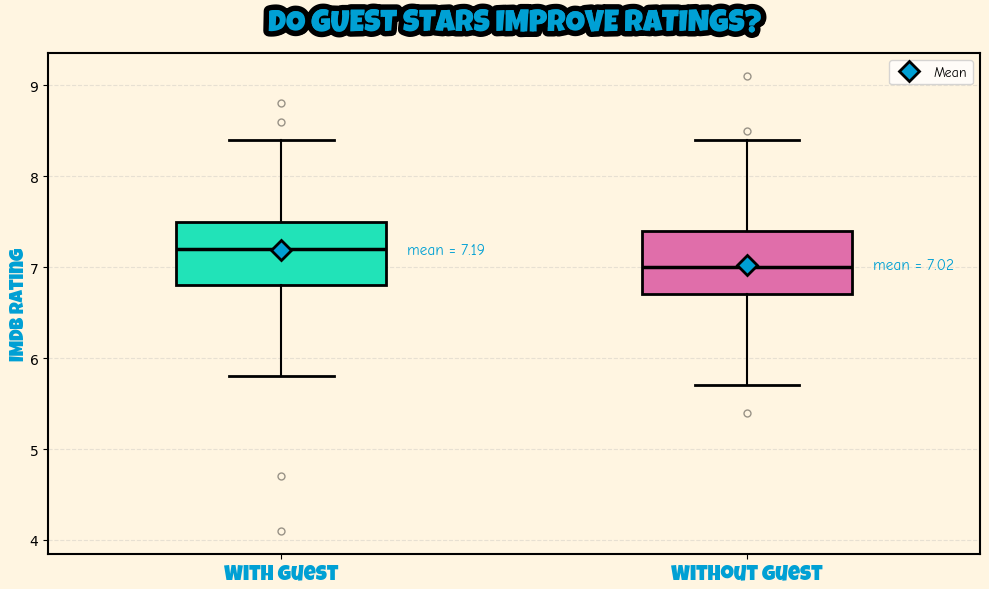

In [15]:
# Boxplot: rating distribution — with guest vs without
# Same structure as the music boxplot — allows direct visual comparison between sections.
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

groups = [
    df[df['has_guest']]['IMDb Rating'].dropna(),
    df[~df['has_guest']]['IMDb Rating'].dropna()
]
labels = ['With guest', 'Without guest']
colors = [GREEN, PINK]

bp = ax.boxplot(
    groups, patch_artist=True, widths=0.45,
    medianprops=dict(color=BLACK, linewidth=2.5),
    whiskerprops=dict(color=BLACK, linewidth=1.5),
    capprops=dict(color=BLACK, linewidth=2),
    flierprops=dict(marker='o', color=BLACK, alpha=0.4, markersize=5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(BLACK)
    patch.set_linewidth(2)

for i, (group, color) in enumerate(zip(groups, colors), start=1):
    ax.plot(i, group.mean(), 'D', color=BLUE,
            markersize=10, markeredgecolor=BLACK, markeredgewidth=2, zorder=5,
            label='Mean' if i == 1 else '')
    ax.annotate(f'mean = {group.mean():.2f}',
                xy=(i + 0.27, group.mean()),
                fontproperties=prop_regular, fontsize=11, color=BLUE, va='center')

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontproperties=prop, fontsize=15, color=BLUE)

title_obj = ax.set_title('DO GUEST STARS IMPROVE RATINGS?',
                          fontproperties=prop, fontsize=22, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_ylabel('IMDb Rating', fontproperties=prop, fontsize=14, color=BLUE)
ax.grid(visible=True, axis='y', alpha=0.3, linestyle='--')
ax.legend(prop=prop_regular, fontsize=10)

for spine in ax.spines.values():
    spine.set_color(BLACK)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


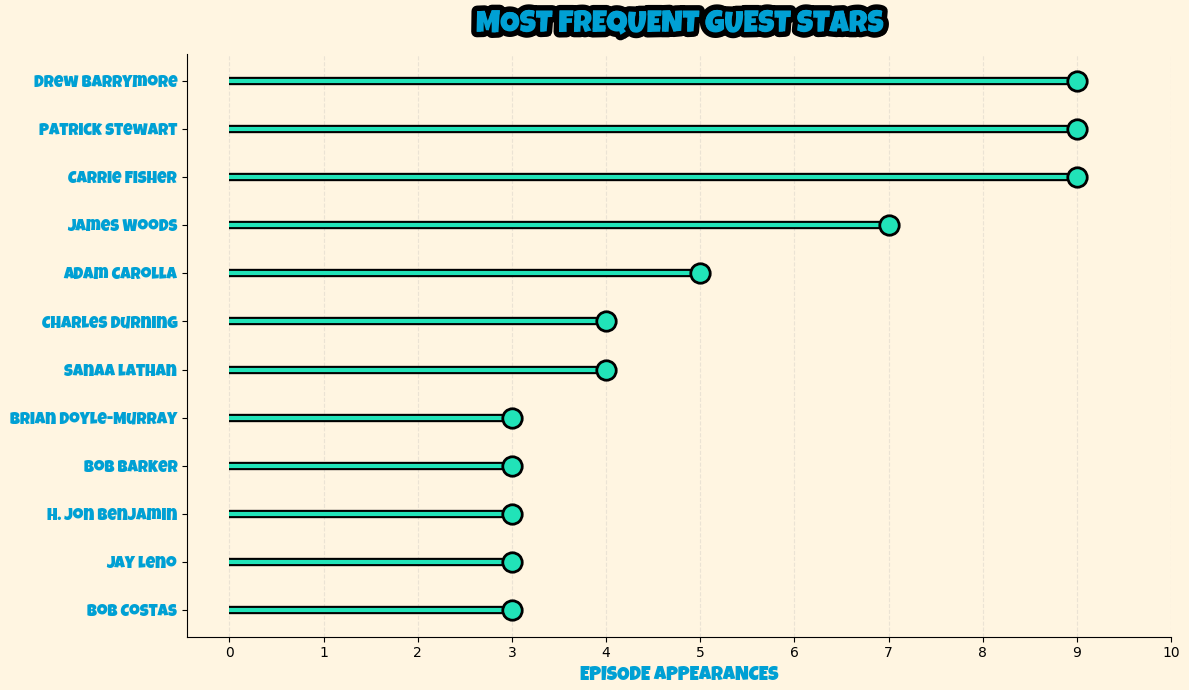

In [16]:
# Lollipop: top 12 most frequent guest stars
# Simple count of how many episodes each guest appeared in.
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

nombres = top_guests.index
conteos = top_guests.values

ax.hlines(y=nombres, xmin=0, xmax=conteos, color=BLACK, linewidth=6)
ax.hlines(y=nombres, xmin=0, xmax=conteos, color=GREEN,  linewidth=3)
ax.plot(conteos, nombres, 'o', markersize=14,
        color=GREEN, markeredgecolor=BLACK, markeredgewidth=2)

ax.set_yticks(range(len(nombres)))
ax.set_yticklabels(nombres, fontproperties=prop, fontsize=12, color=BLUE)

title_obj = ax.set_title('MOST FREQUENT GUEST STARS',
                          fontproperties=prop, fontsize=22, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_xlabel('EPISODE APPEARANCES', fontproperties=prop, fontsize=14, color=BLUE)
ax.set_xticks(range(0, conteos.max() + 2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(BLACK)
ax.spines['bottom'].set_color(BLACK)
ax.grid(axis='x', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()


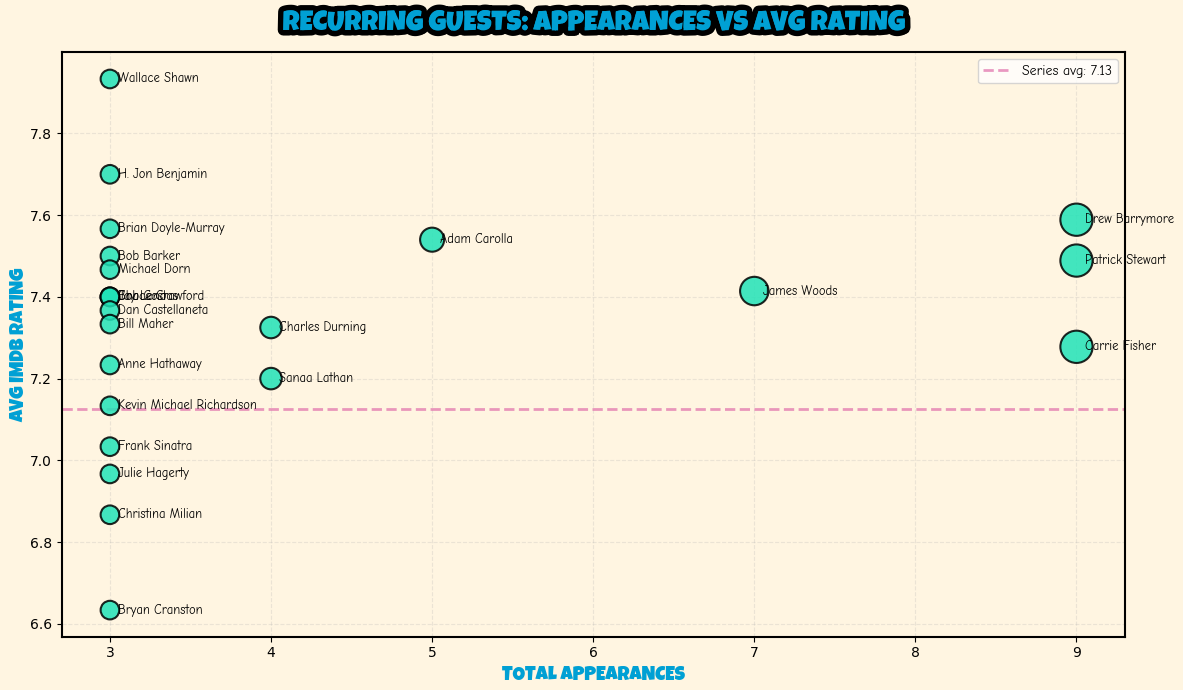

In [17]:
# Scatter: recurring guests — appearances vs average rating
# This is the most interesting guest chart: quantity vs quality.
# Each bubble = one recurring guest (3+ episodes).
# X axis = how many episodes they appeared in.
# Y axis = average IMDb rating of those episodes.
# Bubble size = also proportional to appearances, for extra emphasis.
# Guests above the dashed line (series average) made the show better on average.
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.scatter(
    guest_stats['apariciones'], guest_stats['avg_rating'],
    s=guest_stats['apariciones'] * 60,  # bubble size proportional to appearances
    color=GREEN, edgecolors=BLACK, linewidths=1.5, alpha=0.85, zorder=3
)

# Dashed reference line at the overall series average rating
mean_rating = df['IMDb Rating'].mean()
ax.axhline(mean_rating, color=PINK, linewidth=2, linestyle='--', alpha=0.7,
           label=f'Series avg: {mean_rating:.2f}')

# Label each bubble with the guest's name
for name, row in guest_stats.iterrows():
    ax.annotate(name,
                xy=(row['apariciones'], row['avg_rating']),
                xytext=(6, 0), textcoords='offset points',
                fontproperties=prop_regular, fontsize=9, color=BLACK, va='center')

title_obj = ax.set_title('RECURRING GUESTS: APPEARANCES VS AVG RATING',
                          fontproperties=prop, fontsize=20, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_xlabel('TOTAL APPEARANCES', fontproperties=prop, fontsize=14, color=BLUE)
ax.set_ylabel('AVG IMDb RATING', fontproperties=prop, fontsize=14, color=BLUE)
ax.legend(prop=prop_regular, fontsize=11)
ax.grid(alpha=0.25, linestyle='--')

#box edition
for spine in ax.spines.values():
    spine.set_color(BLACK)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


## 7. Special Episodes (Running Time)

The typical Family Guy episode clocks in at **22 minutes**. But 122 episodes go longer, and 7 of them break the 44-minute mark — proper TV movies. The question: do longer episodes actually earn it, or is extra runtime just extra runtime?

| Category | Duration | Count |
|---|---|---|
| Normal | ≤ 22 min | 278 |
| Extended | 23–30 min | 115 |
| Special | 44+ min | 7 |

**Key findings:**
- Specials average **7.94** — nearly 1 full point above normal episodes (6.96).
- *Road to the Multiverse* (S8, 30 min) scores **9.1** — proof that format alone doesn't guarantee quality.
- *And Then There Were Fewer* (S9, 49 min) is the highest-rated special at **8.6**, with 9.4 million viewers.
- Every single special (44+ min) scores above the series average of ~7.1.


In [18]:
# Categorize episodes by running time
# We define three buckets that match natural breaks in the data:
# - Normal: the standard 22-min format
# - Extended: a bit longer, but not a full special
# - Special: 44+ minutes, basically a TV movie
def categorize(rt):
    if rt <= 22:   return 'Normal\n(≤22 min)'
    elif rt <= 30: return 'Extended\n(23–30 min)'
    else:          return 'Special\n(44+ min)'

df['category'] = df['Running Time (Minutes)'].apply(categorize)

CAT_ORDER  = ['Normal\n(≤22 min)', 'Extended\n(23–30 min)', 'Special\n(44+ min)']
CAT_COLORS = [PINK, BLUE, GREEN]  # consistent color per category across all charts in this section

# Isolate the 7 full specials for individual labelling in the scatter
top_specials = df[df['Running Time (Minutes)'] >= 44].sort_values('IMDb Rating', ascending=False)

print('Special episodes (44+ min):')
print(top_specials[['Season', 'Title of the Episode', 'Running Time (Minutes)',
                     'IMDb Rating', 'U.S. Viewers (Millions)']].to_string(index=False))


Special episodes (44+ min):
 Season                       Title of the Episode  Running Time (Minutes)  IMDb Rating  U.S. Viewers (Millions)
      9                  And Then There Were Fewer                      49          8.6                     9.41
     13                           The Simpsons Guy                      44          8.4                     8.45
      6                               Blue Harvest                      48          8.2                    10.86
      9                     Road to the North Pole                      44          8.2                     8.03
      8 Something, Something, Something, Dark Side                      44          7.6                     6.13
      8                Partial Terms of Endearment                      48          7.4                      NaN
      9                               It's a Trap!                      56          7.2                     5.83


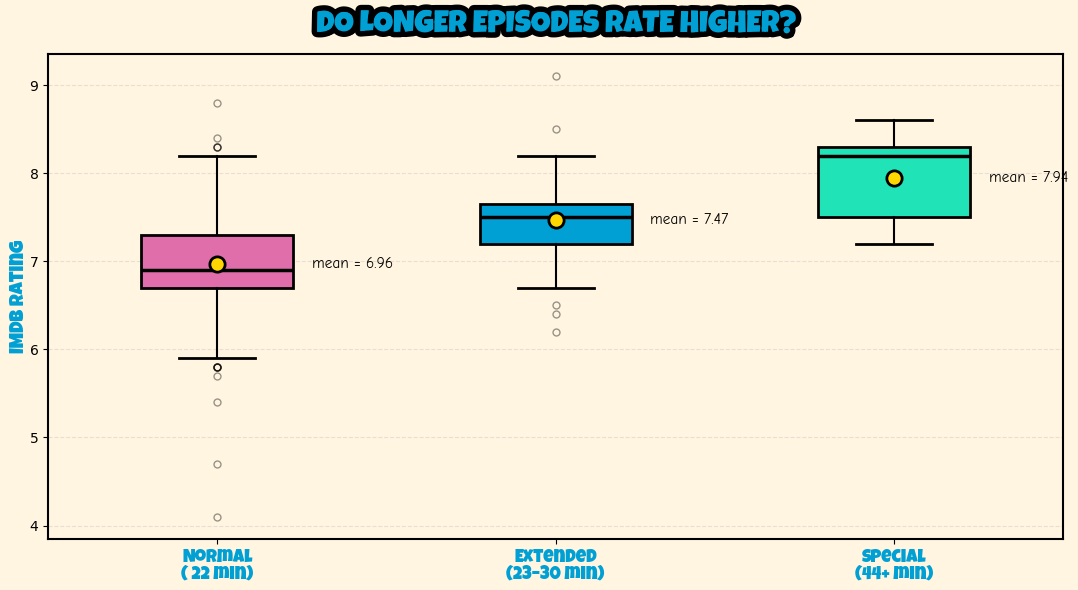

In [19]:
# Boxplot: rating by episode category
# Three boxes — one per category — let us see at a glance whether
# the rating distributions overlap or are clearly separated.
# The yellow circle marks the mean for each category.
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Build the three groups in the same order as CAT_ORDER
groups = [df[df['category'] == cat]['IMDb Rating'].dropna() for cat in CAT_ORDER]

bp = ax.boxplot(
    groups, patch_artist=True, widths=0.45,
    medianprops=dict(color=BLACK, linewidth=2.5), #mean inside the box
    whiskerprops=dict(color=BLACK, linewidth=1.5), #lines outside the box
    capprops=dict(color=BLACK, linewidth=2),
    flierprops=dict(marker='o', color=BLACK, alpha=0.4, markersize=5)
)

for patch, color in zip(bp['boxes'], CAT_COLORS):
    patch.set_facecolor(color)
    patch.set_edgecolor(BLACK)
    patch.set_linewidth(2)

#Each group of the rating with its associated color, enumerates the index

for i, (group, color) in enumerate(zip(groups, CAT_COLORS), start=1):
    ax.plot(i, group.mean(), 'o', color=YELLOW,
            markersize=11, markeredgecolor=BLACK, markeredgewidth=2, zorder=5) #zorder --> makes the dot in front
    ax.annotate(f'mean = {group.mean():.2f}',
                xy=(i + 0.28, group.mean()), #slightly to the right of the dot
                fontproperties=prop_regular, fontsize=11, color=BLACK, va='center')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(CAT_ORDER, fontproperties=prop, fontsize=13, color=BLUE)

title_obj = ax.set_title('DO LONGER EPISODES RATE HIGHER?',
                        fontproperties=prop, fontsize=22, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_ylabel('IMDb Rating', fontproperties=prop, fontsize=14, color=BLUE)
ax.grid(visible=True, axis='y', alpha=0.3, linestyle='--')

for spine in ax.spines.values():
    spine.set_color(BLACK)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


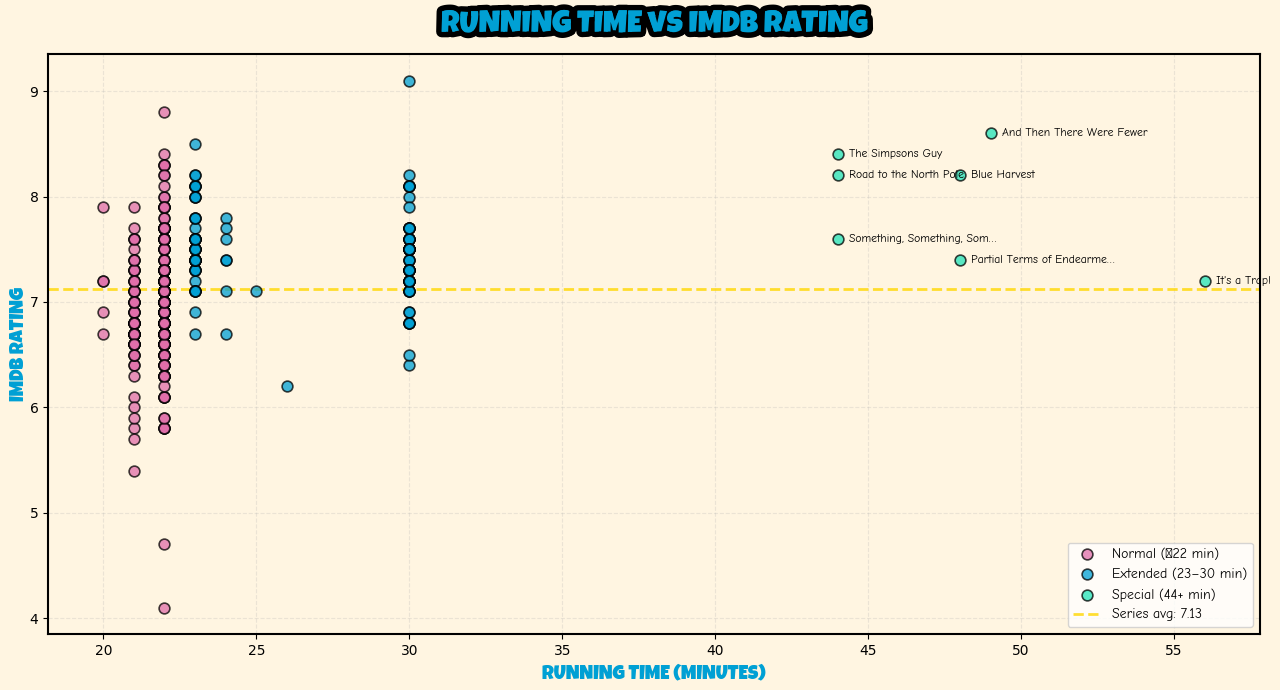

In [20]:
# Scatter: running time vs IMDb rating
# Every dot is one episode, colored by category.
# The 7 full specials (44+ min) are individually labelled so we can see exactly which episodes they are and where they land.
# The dashed yellow line = series average — everything above it beats the mean.
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Plot each category as a separate scatter layer so the legend works correctly
for cat, color in zip(CAT_ORDER, CAT_COLORS):
    subset = df[df['category'] == cat]
    ax.scatter(subset['Running Time (Minutes)'], subset['IMDb Rating'],
               color=color, edgecolors=BLACK, linewidths=1.2,
               s=60, alpha=0.75, zorder=3,
               label=cat.replace('\n', ' '))

# Label the specials individually
for _, row in top_specials.iterrows():
    short_title = row['Title of the Episode'][:25] + ('…' if len(row['Title of the Episode']) > 25 else '')
    ax.annotate(short_title,
                xy=(row['Running Time (Minutes)'], row['IMDb Rating']),
                xytext=(8, 0), textcoords='offset points',
                fontproperties=prop_regular, fontsize=8.5, color=BLACK, va='center')

mean_r = df['IMDb Rating'].mean()
ax.axhline(mean_r, color=YELLOW, linewidth=2, linestyle='--', alpha=0.8,
           label=f'Series avg: {mean_r:.2f}')

title_obj = ax.set_title('RUNNING TIME vs IMDb RATING',
                          fontproperties=prop, fontsize=22, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_xlabel('RUNNING TIME (MINUTES)', fontproperties=prop, fontsize=14, color=BLUE)
ax.set_ylabel('IMDb RATING', fontproperties=prop, fontsize=14, color=BLUE)
ax.legend(prop=prop_regular, fontsize=10)
ax.grid(alpha=0.25, linestyle='--')

for spine in ax.spines.values():
    spine.set_color(BLACK)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


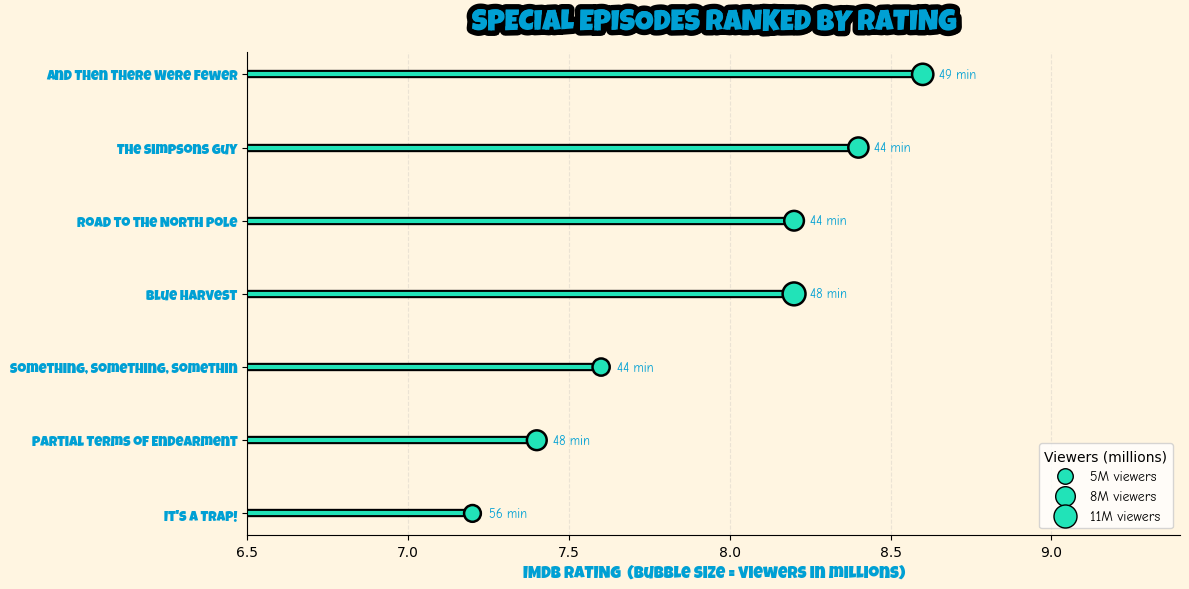

In [21]:
# Lollipop: special episodes ranked by rating
# Only the 7 full specials (44+ min), sorted from lowest to highest rating.
# Bubble size = U.S. viewership in millions — bigger audience, bigger dot.
# The runtime annotation next to each dot adds a third dimension of info.
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sp = top_specials.sort_values('IMDb Rating').dropna(subset=['IMDb Rating'])
nombres = sp['Title of the Episode'].str[:30]
ratings = sp['IMDb Rating']
# Fill missing viewer data with the column mean so no bubble disappears
viewers = sp['U.S. Viewers (Millions)'].fillna(sp['U.S. Viewers (Millions)'].mean())

ax.hlines(y=range(len(sp)), xmin=6.5, xmax=ratings, color=BLACK, linewidth=6)
ax.hlines(y=range(len(sp)), xmin=6.5, xmax=ratings, color=GREEN, linewidth=3)
ax.scatter(ratings, range(len(sp)),
           s=viewers * 25,  # scale factor: 1M viewers → 25 pts^2 of area
           color=GREEN, edgecolors=BLACK, linewidths=1.8, zorder=5)

# Annotate each episode with its runtime
for i, (_, row) in enumerate(sp.iterrows()):
    ax.annotate(f"{int(row['Running Time (Minutes)'])} min",
                xy=(row['IMDb Rating'] + 0.05, i),
                fontproperties=prop_regular, fontsize=9, color=BLUE, va='center')

ax.set_yticks(range(len(sp)))
ax.set_yticklabels(nombres, fontproperties=prop, fontsize=10, color=BLUE)
ax.set_xlim(6.5, 9.4)

title_obj = ax.set_title('SPECIAL EPISODES RANKED BY RATING',
                          fontproperties=prop, fontsize=21, color=BLUE, pad=16)
title_obj.set_path_effects(title_effect())

ax.set_xlabel('IMDb RATING  (bubble size = viewers in millions)',
              fontproperties=prop, fontsize=12, color=BLUE)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(BLACK)
ax.spines['bottom'].set_color(BLACK)
ax.grid(axis='x', alpha=0.25, linestyle='--')

# Legend showing what bubble sizes mean
# Sizes chosen to match the actual viewer range in the dataset (5–11M)
sizes  = [5, 8, 11]
markers = [plt.scatter([], [], s=s * 25, color=GREEN, edgecolors=BLACK) for s in sizes]
labels  = [f'{s}M viewers' for s in sizes]

ax.legend(markers, labels,
          title='Viewers (millions)',
          prop=prop_regular,
          fontsize=10,
          loc='lower right',
          frameon=True)

plt.tight_layout()
plt.show()


## 8. Conclusions & Key Findings

400 episodes, 21 seasons, a lot of chicken fights. Here's what the data actually tells us:

**The golden era was real** — Seasons 4 and 5 sit at the top of the ratings chart, and it's not close. The show has been on a slow but pretty clear downward trend since then. The gap between the best and worst episode within each season has also widened in later years, which suggests more inconsistency, not just lower averages.

**Musical episodes are (slightly) better** — episodes with at least one song average +0.24 points higher on IMDb. That might sound small, but it's consistent across most seasons, and in some seasons (3, 6, 13) the gap reaches +0.4. One possible read: the writers save the musical numbers for episodes they already feel good about.

**Guest stars help, but less than you'd think** — there's a +0.17 boost on average, but it almost disappears in later seasons. And more appearances ≠ better episodes: Wallace Shawn (3 eps, avg 7.93) comfortably outperforms Carrie Fisher (9 eps, avg 7.28). Quality of guest matters more than quantity.

**Longer episodes are consistently better** — specials (44+ min) average 7.94 vs 6.96 for standard episodes, and every single one of the 7 specials scores above the series mean. Whether longer runtime enables better storytelling, or whether the writers only pitch specials when they have a genuinely great idea — impossible to tell from the data alone. But the pattern is clear.

---
*Dataset source: [Family Guy Dataset — Kaggle](https://www.kaggle.com/datasets/iamsouravbanerjee/family-guy-dataset)*  
*Notebook by Nano Vives · 2026*
